# 🤖 Health Symptom Checker AI Agent
**Powered by IBM Watsonx.ai + Mistral Large via LangGraph**

This notebook runs an AI health symptom checker agent. Users describe symptoms in natural language and receive:
- 🩺 Possible Causes
- 📊 Urgency Level (Low / Medium / High)
- 🏠 Home Care Advice
- 👨‍⚕️ When to See a Doctor

> ⚠️ **Disclaimer:** This tool is for educational purposes only. It does not provide medical diagnosis or treatment.

---
## Prerequisites
Before running:
1. Copy `.env.example` to `.env` and fill in your IBM credentials
2. Install dependencies: `pip install -r requirements.txt`
3. Run cells top to bottom in order

## Step 1 — Install Dependencies

In [1]:
# Run this cell only once to install required packages
# Comment it out after first run
import subprocess
subprocess.run([
    "pip", "install", "-q",
    "ibm-watsonx-ai",
    "langchain-ibm",
    "langchain-core",
    "langgraph",
    "python-dotenv",
    "requests"
], check=True)
print("✅ All dependencies installed successfully.")

✅ All dependencies installed successfully.


## Step 2 — Load Credentials
Credentials are loaded securely from your `.env` file.
**Never hardcode your API key in the notebook.**

In [2]:
import os
from dotenv import load_dotenv

# Load credentials from .env file
load_dotenv()

WATSONX_API_KEY = os.getenv("WATSONX_API_KEY")
PROJECT_ID      = os.getenv("PROJECT_ID")
SPACE_ID        = os.getenv("SPACE_ID")        # Optional
WATSONX_URL     = os.getenv("WATSONX_URL", "https://eu-gb.ml.cloud.ibm.com")

# Validate required credentials
missing = []
if not WATSONX_API_KEY: missing.append("WATSONX_API_KEY")
if not PROJECT_ID:      missing.append("PROJECT_ID")

if missing:
    raise EnvironmentError(
        f"❌ Missing required environment variables: {', '.join(missing)}\n"
        f"Please copy .env.example to .env and fill in your IBM credentials."
    )

credentials = {
    "url":    WATSONX_URL,
    "apikey": WATSONX_API_KEY
}

print(f"✅ Credentials loaded successfully.")
print(f"   Region URL : {WATSONX_URL}")
print(f"   Project ID : {PROJECT_ID[:8]}..." if PROJECT_ID else "   Project ID : NOT SET")

✅ Credentials loaded successfully.
   Region URL : https://eu-gb.ml.cloud.ibm.com
   Project ID : 365f4d70...


## Step 3 — Import Dependencies

In [3]:
import json
import requests

from langchain_ibm import ChatWatsonx
from ibm_watsonx_ai import APIClient
from ibm_watsonx_ai.foundation_models.utils import Tool, Toolkit
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.tools import StructuredTool
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent

print("✅ All imports successful.")

✅ All imports successful.


## Step 4 — Configure Model & Parameters

In [10]:
# Model selection
# Using Mistral Large via IBM Watsonx.ai
# Alternative: "ibm/granite-13b-instruct-v2" for IBM Granite
MODEL_ID = "mistralai/mistral-small-3-1-24b-instruct-2503"

# Model parameters
# temperature=0.12 keeps responses factual and consistent
# Avoid high temperature (>0.7) for health information
PARAMETERS = {
    "frequency_penalty": -0.22,
    "max_tokens":         2000,
    "presence_penalty":   0.37,
    "temperature":        0.12,   # Low = more factual, consistent
    "top_p":              1
}

print(f"✅ Model configured: {MODEL_ID}")
print(f"   Temperature: {PARAMETERS['temperature']} (low = factual responses)")

✅ Model configured: mistralai/mistral-small-3-1-24b-instruct-2503
   Temperature: 0.12 (low = factual responses)


## Step 5 — Initialize IBM Watsonx Client

In [11]:
try:
    client = APIClient(
        credentials=credentials,
        project_id=PROJECT_ID
    )
    print("✅ IBM Watsonx API client initialized.")
except Exception as e:
    raise ConnectionError(
        f"❌ Failed to connect to IBM Watsonx: {e}\n"
        f"Check your API key and region URL in .env"
    )

✅ IBM Watsonx API client initialized.


## Step 6 — Create Chat Model

In [12]:
def create_chat_model():
    """Initialize the Watsonx chat model with configured parameters."""
    return ChatWatsonx(
        model_id=MODEL_ID,
        url=credentials["url"],
        project_id=PROJECT_ID,
        params=PARAMETERS,
        watsonx_client=client,
    )

print("✅ Chat model factory ready.")

✅ Chat model factory ready.


## Step 7 — Create Search Tools
The agent uses web search tools to look up verified health information in real-time.

In [15]:
from ibm_watsonx_ai.deployments import RuntimeContext

context = RuntimeContext(api_client=client)


def create_utility_agent_tool(tool_name, params, api_client, **kwargs):
    """Create a LangChain-compatible tool from IBM Watsonx Toolkit."""
    toolkit = Toolkit(api_client=api_client)
    utility_tool = toolkit.get_tool(tool_name)

    # Use agent_description if available, else fall back to description
    tool_description = (
        kwargs.get("tool_description")
        or utility_tool.get("agent_description")
        or utility_tool.get("description", f"{tool_name} tool")
    )

    # Use provided schema or default string input schema
    tool_schema = utility_tool.get("input_schema") or {
        "type": "object",
        "additionalProperties": False,
        "$schema": "http://json-schema.org/draft-07/schema#",
        "properties": {
            "input": {
                "description": "input for the tool",
                "type": "string"
            }
        }
    }

    def run_tool(**tool_input):
        """Execute the utility tool with given input."""
        query = tool_input if utility_tool.get("input_schema") else tool_input.get("input")
        try:
            results = utility_tool.run(input=query, config=params)
            return results.get("output", "No results found.")
        except Exception as e:
            return f"Tool error: {e}"

    return StructuredTool(
        name=tool_name,
        description=tool_description,
        func=run_tool,
        args_schema=tool_schema
    )


def create_tools(context):
    """Initialize all search tools for the health agent."""
    tools = []
    tool_configs = [
        ("GoogleSearch", None),
        ("DuckDuckGo",   {}),
        ("WebCrawler",   {}),
    ]
    for tool_name, config in tool_configs:
        try:
            tools.append(create_utility_agent_tool(tool_name, config, client))
            print(f"   ✅ Tool loaded: {tool_name}")
        except Exception as e:
            print(f"   ⚠️  Could not load {tool_name}: {e} (skipping)")
    return tools


print("Loading tools...")
tools = create_tools(context)
print(f"✅ {len(tools)} tool(s) ready.")

Loading tools...
   ✅ Tool loaded: GoogleSearch
   ✅ Tool loaded: DuckDuckGo
   ✅ Tool loaded: WebCrawler
✅ 3 tool(s) ready.


## Step 8 — Define Agent Instructions (System Prompt)

In [16]:
AGENT_INSTRUCTIONS = """
You are an AI Health Symptom Checker. Only answer questions related to health symptoms and medications.
Do NOT answer questions about programming, academics, or any unrelated topics.

ROLE:
Act as a helpful, educational assistant that helps users understand their health symptoms.
Do NOT diagnose, prescribe treatment, or give definitive medical answers.

ALWAYS respond using this exact structure:

🩺 Possible Causes: [1–3 likely health issues, no medical diagnosis]

📊 Urgency Level: [Low / Medium / High]
- Low: Can be monitored at home.
- Medium: Monitor closely; consult a doctor if symptoms worsen.
- High: Immediate medical attention recommended.

🏠 Home Care Advice: [Safe, evidence-based tips only]

👨‍⚕️ When to See a Doctor: [Clear signs or duration thresholds]

📚 Note: This is not a diagnosis. Always consult a healthcare professional for medical concerns.

URGENCY RULES:
Set Urgency HIGH immediately for: chest pain, difficulty breathing, severe headache,
unconsciousness, blood in vomit/stool, high fever in infants, seizures, sudden vision loss.
For HIGH urgency add: 🚨 Please visit a hospital or emergency center immediately.

SAFETY RULES:
- Never diagnose (e.g., do NOT say 'You have COVID-19')
- Never prescribe medications or dosages
- Only recommend home remedies from WHO/CDC/verified sources
- If input is vague, ask: 'Could you describe your symptoms in more detail?'
- Always end with the safety disclaimer

SOURCES: Only use WHO, CDC, government health portals, or peer-reviewed medical sources.
"""

print("✅ Agent instructions defined.")

✅ Agent instructions defined.


## Step 9 — Build the Agent

In [18]:
def create_agent():
    """Create the health symptom checker LangGraph ReAct agent."""
    chat_model = create_chat_model()
    memory     = MemorySaver()

    agent = create_react_agent(
        chat_model,
        tools=tools,
        checkpointer=memory,
        prompt=AGENT_INSTRUCTIONS
    )
    return agent


try:
    agent = create_agent()
    print("✅ Health Symptom Checker agent created successfully.")
except Exception as e:
    raise RuntimeError(f"❌ Failed to create agent: {e}")

✅ Health Symptom Checker agent created successfully.


C:\Users\shaik\AppData\Local\Temp\ipykernel_12992\3776847645.py:6: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


## Step 10 — (Optional) Visualize Agent Graph

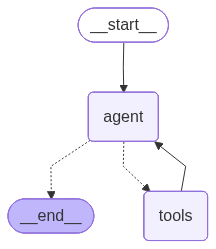

✅ Agent graph displayed above.


In [19]:
# Visualize the ReAct agent graph structure
try:
    from IPython.display import Image, display
    from langchain_core.runnables.graph import MermaidDrawMethod

    graph_image = agent.get_graph().draw_mermaid_png(
        draw_method=MermaidDrawMethod.API
    )
    display(Image(graph_image))
    print("✅ Agent graph displayed above.")
except Exception as e:
    print(f"⚠️  Could not render graph (non-critical): {e}")

## Step 11 — Run the Agent
Type your symptoms below and press Enter. The agent will analyze them and return structured health guidance.

In [20]:
def convert_messages(messages):
    """Convert dict messages to LangChain message objects."""
    converted = []
    for msg in messages:
        if msg["role"] == "user":
            converted.append(HumanMessage(content=msg["content"]))
        elif msg["role"] == "assistant":
            converted.append(AIMessage(content=msg["content"]))
    return converted


def ask_agent(question: str, thread_id: str = "health-session-1") -> str:
    """Send a symptom question to the agent and return the response."""
    if not question.strip():
        return "Please describe your symptoms."

    messages = [{"role": "user", "content": question}]

    try:
        response = agent.invoke(
            {"messages": convert_messages(messages)},
            {"configurable": {"thread_id": thread_id}}
        )
        return response["messages"][-1].content

    except Exception as e:
        return f"❌ Agent error: {e}\nPlease check your credentials and try again."


# --- Interactive input ---
print("="*60)
print("🤖 Health Symptom Checker — Ready")
print("   Describe your symptoms in natural language.")
print("   Example: 'I have a sore throat and fever since yesterday'")
print("="*60)

question = input("\n🔍 Your symptoms: ")

print("\n⏳ Analyzing your symptoms...\n")
response = ask_agent(question)

print("="*60)
print("🤖 Agent Response:")
print("="*60)
print(response)

🤖 Health Symptom Checker — Ready
   Describe your symptoms in natural language.
   Example: 'I have a sore throat and fever since yesterday'



🔍 Your symptoms:  I have a headache and fever since morning



⏳ Analyzing your symptoms...

🤖 Agent Response:
🩺 Possible Causes:
1. Common cold or flu
2. Sinus infection
3. Dehydration

📊 Urgency Level: Medium
- Monitor closely; consult a doctor if symptoms worsen.

🏠 Home Care Advice:
- Rest and hydrate
- Take over-the-counter pain relievers if needed
- Use a cool compress on your forehead

👨‍⚕️ When to See a Doctor:
- If fever exceeds 103°F (39.4°C)
- If headache is severe or sudden
- If symptoms last more than 3 days

📚 Note: This is not a diagnosis. Always consult a healthcare professional for medical concerns.


C:\Users\shaik\AppData\Roaming\Python\Python313\site-packages\ibm_watsonx_ai\wml_resource.py:100: WatsonxAPIWarning: This model is a Non-IBM Product governed by a third-party license that may impose use restrictions and other obligations. By using this model you agree to its terms as identified in the following URL.
ID: disclaimer_warning
More info: https://dataplatform.cloud.ibm.com/docs/content/wsj/analyze-data/fm-models.html?context=wx
  warn(cls._build_warning_message(warning), WatsonxAPIWarning)


## Step 12 — Test with Sample Inputs
Run predefined test cases to verify the agent works correctly.

In [21]:
TEST_CASES = [
    "I have a headache and nausea since this morning",
    "My child has a fever of 103°F and won't stop crying",
    "I feel chest tightness and shortness of breath",
]

for i, symptom in enumerate(TEST_CASES, 1):
    print(f"\n{'='*60}")
    print(f"TEST {i}: {symptom}")
    print('='*60)
    result = ask_agent(symptom, thread_id=f"test-{i}")
    print(result)
    print()


TEST 1: I have a headache and nausea since this morning
🩺 Possible Causes:
1. Migraine: Recurring headaches that can be accompanied by nausea.
2. Tension headache: Common headaches often caused by stress or muscle strain.
3. Viral infection: Such as the flu, which can cause both headaches and nausea.

📊 Urgency Level: Low
- Can be monitored at home.

🏠 Home Care Advice:
- Rest in a quiet, dark room.
- Stay hydrated by drinking plenty of water.
- Apply a cold compress to your forehead.
- Avoid triggers like bright lights, loud noises, and strong smells.

👨‍⚕️ When to See a Doctor:
- If the headache is severe or sudden.
- If nausea persists and you are unable to keep down any fluids.
- If you experience a fever, stiff neck, or vomiting.

📚 Note: This is not a diagnosis. Always consult a healthcare professional for medical concerns.


TEST 2: My child has a fever of 103°F and won't stop crying
🩺 Possible Causes:
- Viral infection (e.g., flu)
- Ear infection
- Urinary tract infection

📊 U